# 07. Innovation Diffusion and Replication Patterns

Explore how innovation signals recur across projects, countries, and time.

This analysis is descriptive. It identifies recurrence, replication, and scaling
signals but does not establish causal diffusion between projects.

In [28]:
# --------------------------------------------------
# IMPORTS AND PATHS
# --------------------------------------------------
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
from pathlib import Path
import ast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT       = Path("..").resolve()
OUTPUT_DIR = ROOT / "outputs"
DATA_DIR   = ROOT / "data"
META_DIR   = DATA_DIR / "metadata"

DIFFUSION_DIR = OUTPUT_DIR / "diffusion"
DIFFUSION_DIR.mkdir(parents=True, exist_ok=True)

INNOVATION_SIGNALS = {"innovation", "possible_innovation"}

## 2. Attach project geography and year

Innovation classifications are linked back to the original PAD corpus metadata
so recurrence can be examined across countries and over time.

In [16]:
# --------------------------------------------------
# LOAD CLASSIFICATION RESULTS
# --------------------------------------------------

results_df = pd.read_csv(OUTPUT_DIR / "innovation_classification_results.csv")

analysis_df = results_df[results_df["innovation_presence"] != "error"].copy()

print("Classified units available:", len(analysis_df))

Classified units available: 61


In [17]:
# --------------------------------------------------
# LOAD MANIFEST AND ATTACH METADATA
# --------------------------------------------------

manifest_df = pd.read_csv(META_DIR / "pad_corpus_manifest.csv")
manifest_df["document_year"] = pd.to_datetime(manifest_df["docdt"], errors="coerce").dt.year

project_meta_df = (
    manifest_df[["projectid", "count", "admreg", "document_year", "display_title"]]
    .sort_values("document_year")
    .drop_duplicates(subset=["projectid"], keep="last")
    .rename(columns={"count": "country", "display_title": "project_title"})
)

analysis_df = analysis_df.merge(
    project_meta_df, on="projectid", how="left", validate="many_to_one"
)

print("Manifest records  :", len(manifest_df))
print("Unique projects   :", manifest_df["projectid"].nunique())
print("Classified units  :", len(analysis_df))
print("With country      :", analysis_df["country"].notna().sum())
print("With year         :", analysis_df["document_year"].notna().sum())

Manifest records  : 353
Unique projects   : 348
Classified units  : 61
With country      : 61
With year         : 61


Normalize innovation types and build long-format signal frame

## 3. Normalize innovation-type labels

The classification output stores one or more innovation types per analytical unit.

These labels are converted back into lists so we can examine recurrence across
projects, countries, and years.

In [18]:
# --------------------------------------------------
# NORMALIZE INNOVATION TYPES
# --------------------------------------------------

def parse_innovation_types(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    value = str(value).strip()
    if not value or value == "[]":
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

analysis_df["innovation_type_list"] = analysis_df["innovation_types"].apply(parse_innovation_types)

innovation_signal_df = analysis_df[
    analysis_df["innovation_presence"].isin(INNOVATION_SIGNALS)
].copy()

innovation_types_long_df = (
    innovation_signal_df[["projectid", "country", "document_year",
                           "innovation_presence", "innovation_type_list"]]
    .explode("innovation_type_list")
    .rename(columns={"innovation_type_list": "innovation_type"})
    .dropna(subset=["innovation_type"])
    .copy()
)

print("Innovation-signal units :", len(innovation_signal_df))
print("Long-format type rows   :", len(innovation_types_long_df))
print()
display(
    innovation_types_long_df["innovation_type"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "innovation_type", "innovation_type": "classified_units"})
)

Innovation-signal units : 49
Long-format type rows   : 121



,classified_units,count
0,process_service_delivery,36
1,institutional_governance,31
2,digital_data_technology,20
3,financing_instrument,16
4,product_service,10
5,policy_regulatory,8


Temporal analysis and plot

In [19]:
# --------------------------------------------------
# ATTACH SOURCE TEXT FOR KEYWORD ANALYSIS
# --------------------------------------------------

units_df = pd.read_csv(
    ROOT / "data" / "processed" / "pad_components_subcomponents.csv"
)

def normalize_unit_number(value):
    if pd.isna(value):
        return ""
    value = str(value).strip()
    if value.endswith(".0"):
        value = value[:-2]
    return value

analysis_df["number_key"] = analysis_df["number"].apply(normalize_unit_number)
units_df["number_key"]    = units_df["number"].apply(normalize_unit_number)

analysis_df = analysis_df.merge(
    units_df[["projectid", "type", "number_key", "text"]],
    on=["projectid", "type", "number_key"],
    how="left",
    validate="many_to_one",
)

print("Units with source text:", analysis_df["text"].notna().sum())
print("Units missing text    :", analysis_df["text"].isna().sum())

Units with source text: 61
Units missing text    : 0


innovation_type,digital_data_technology,financing_instrument,institutional_governance,policy_regulatory,process_service_delivery,product_service
document_year,,,,,,
2016,1,2,3,0,1,1
2017,0,0,2,1,2,2
2018,2,0,2,1,3,2
2019,0,2,1,0,1,0
2020,2,2,3,0,3,1
2021,4,4,4,2,5,1
2023,1,0,1,1,1,0
2025,1,1,1,1,1,1


,innovation_type,first_observed_year,last_observed_year,distinct_years,distinct_projects
0,digital_data_technology,2016,2025,6,11
1,financing_instrument,2016,2025,5,11
2,institutional_governance,2016,2025,8,17
4,process_service_delivery,2016,2025,8,17
5,product_service,2016,2025,6,8
3,policy_regulatory,2017,2025,5,6


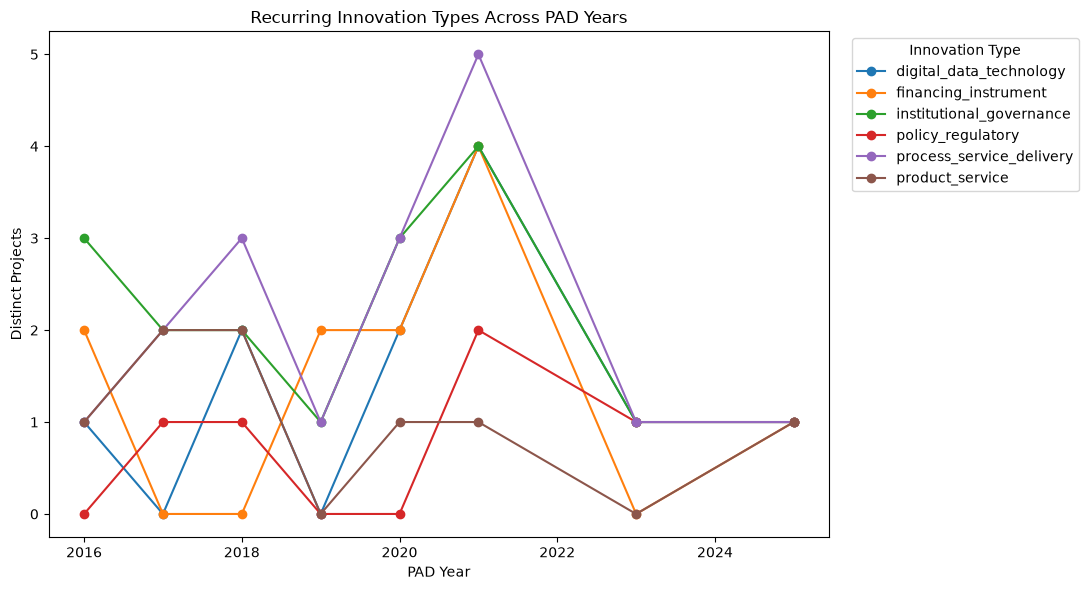

In [20]:
# --------------------------------------------------
# TEMPORAL RECURRENCE
# --------------------------------------------------

temporal_df = (
    innovation_types_long_df
    .dropna(subset=["document_year"])
    .groupby(["document_year", "innovation_type"])
    .agg(distinct_projects=("projectid", "nunique"))
    .reset_index()
)

temporal_pivot = (
    temporal_df
    .pivot(index="document_year", columns="innovation_type", values="distinct_projects")
    .fillna(0)
    .astype(int)
)

type_temporal_summary = (
    innovation_types_long_df
    .dropna(subset=["document_year"])
    .groupby("innovation_type")
    .agg(
        first_observed_year=("document_year", "min"),
        last_observed_year=("document_year", "max"),
        distinct_years=("document_year", "nunique"),
        distinct_projects=("projectid", "nunique"),
    )
    .reset_index()
    .sort_values("first_observed_year")
)

display(temporal_pivot)
display(type_temporal_summary)

ax = temporal_pivot.plot(figsize=(11, 6), marker="o")
ax.set_title("Recurring Innovation Types Across PAD Years")
ax.set_xlabel("PAD Year")
ax.set_ylabel("Distinct Projects")
ax.legend(title="Innovation Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Country-level recurrence

In [21]:
# --------------------------------------------------
# CONFIDENCE-WEIGHTED SIGNAL STRENGTH
# --------------------------------------------------

confidence_long_df = (
    innovation_signal_df
    .assign(confidence=pd.to_numeric(
        innovation_signal_df["confidence"], errors="coerce"
    ))
    .explode("innovation_type_list")
    .rename(columns={"innovation_type_list": "innovation_type"})
    .dropna(subset=["innovation_type", "confidence"])
)

confidence_summary_df = (
    confidence_long_df
    .groupby("innovation_type")
    .agg(
        mean_confidence=("confidence", "mean"),
        weighted_projects=("confidence", "sum"),
        distinct_projects=("projectid", "nunique"),
    )
    .reset_index()
    .sort_values("mean_confidence", ascending=False)
)

confidence_summary_df["mean_confidence"]   = confidence_summary_df["mean_confidence"].round(3)
confidence_summary_df["weighted_projects"] = confidence_summary_df["weighted_projects"].round(1)

display(confidence_summary_df)

,innovation_type,mean_confidence,weighted_projects,distinct_projects
5,product_service,0.766,7.7,8
3,policy_regulatory,0.734,5.9,6
0,digital_data_technology,0.716,14.3,11
1,financing_instrument,0.711,11.4,11
2,institutional_governance,0.703,21.8,17
4,process_service_delivery,0.703,25.3,17


Co-occurrence matrix (distinct project pairs):


type_b,digital_data_technology,financing_instrument,institutional_governance,policy_regulatory,process_service_delivery,product_service
type_a,,,,,,
digital_data_technology,NaN,5.0,9.0,5.0,10.0,5.0
financing_instrument,5.0,0.0,9.0,3.0,7.0,2.0
institutional_governance,9.0,9.0,0.0,6.0,14.0,8.0
policy_regulatory,5.0,3.0,6.0,0.0,6.0,3.0
process_service_delivery,10.0,7.0,14.0,6.0,0.0,7.0
product_service,5.0,2.0,8.0,3.0,7.0,NaN


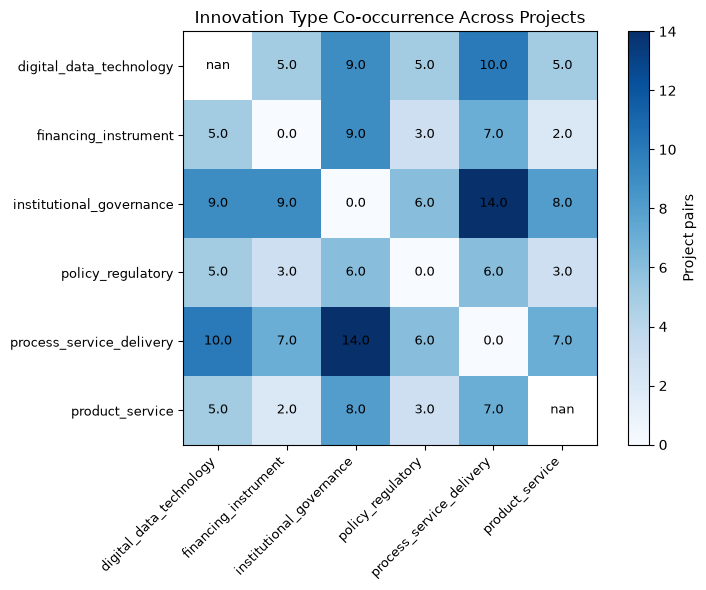

In [22]:
# --------------------------------------------------
# INNOVATION TYPE CO-OCCURRENCE ACROSS PROJECTS
# --------------------------------------------------

pairs = []
for _, grp in innovation_signal_df.groupby("projectid"):
    types = set(grp["innovation_type_list"].explode().dropna())
    for a, b in combinations(sorted(types), 2):
        pairs.append((a, b))

if pairs:
    co_df    = pd.DataFrame(pairs, columns=["type_a", "type_b"])
    co_matrix = pd.crosstab(co_df["type_a"], co_df["type_b"])

    # Symmetrise so both triangles read correctly
    co_matrix = co_matrix.add(co_matrix.T, fill_value=0)

    print("Co-occurrence matrix (distinct project pairs):")
    display(co_matrix)

    # Quick heatmap
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(co_matrix.values, cmap="Blues")
    ax.set_xticks(range(len(co_matrix.columns)))
    ax.set_yticks(range(len(co_matrix.index)))
    ax.set_xticklabels(co_matrix.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(co_matrix.index, fontsize=9)
    for i in range(len(co_matrix.index)):
        for j in range(len(co_matrix.columns)):
            ax.text(j, i, co_matrix.values[i, j], ha="center", va="center", fontsize=9)
    ax.set_title("Innovation Type Co-occurrence Across Projects")
    plt.colorbar(im, ax=ax, label="Project pairs")
    plt.tight_layout()
    plt.show()
else:
    print("No co-occurring innovation types found.")

In [23]:
# --------------------------------------------------
# TF-IDF KEYWORD FINGERPRINT PER INNOVATION TYPE
# --------------------------------------------------

TOP_N_TERMS = 10

# analysis_df already has text from Cell 4b -- filter it directly
signal_text_df = (
    analysis_df[
        analysis_df["innovation_presence"].isin(INNOVATION_SIGNALS)
    ]
    .explode("innovation_type_list")
    .rename(columns={"innovation_type_list": "innovation_type"})
    .dropna(subset=["innovation_type", "text"])
    .copy()
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    ngram_range=(1, 2),
)

tfidf.fit(signal_text_df["text"].astype(str))
feature_names = tfidf.get_feature_names_out()

fingerprint_rows = []

for itype, grp in signal_text_df.groupby("innovation_type"):
    tfidf_matrix = tfidf.transform(grp["text"].astype(str))
    mean_scores  = tfidf_matrix.mean(axis=0).A1
    top_indices  = mean_scores.argsort()[::-1][:TOP_N_TERMS]
    top_terms    = [feature_names[i] for i in top_indices]
    fingerprint_rows.append({
        "innovation_type": itype,
        "top_terms": ", ".join(top_terms),
    })

fingerprint_df = pd.DataFrame(fingerprint_rows).sort_values("innovation_type")

display(fingerprint_df)

,innovation_type,top_terms
0,digital_data_technology,"digital, land, data, project, services, suppor..."
1,financing_instrument,"million, project, grants, digital, private, se..."
2,institutional_governance,"project, digital, support, services, data, lan..."
3,policy_regulatory,"digital, data, regulations, framework, sector,..."
4,process_service_delivery,"project, digital, services, support, managemen..."
5,product_service,"project, maize, practices, dissemination, regi..."


In [24]:
# --------------------------------------------------
# COUNTRY-LEVEL RECURRENCE
# --------------------------------------------------

country_type_pivot = (
    innovation_types_long_df
    .dropna(subset=["country"])
    .groupby(["country", "innovation_type"])
    .agg(distinct_projects=("projectid", "nunique"))
    .reset_index()
    .pivot(index="country", columns="innovation_type", values="distinct_projects")
    .fillna(0)
    .astype(int)
)

display(country_type_pivot.head(20))

innovation_type,digital_data_technology,financing_instrument,institutional_governance,policy_regulatory,process_service_delivery,product_service
country,,,,,,
Africa,0,1,4,0,3,2
Burkina Faso,0,1,0,0,0,0
Cameroon,3,3,3,1,2,1
Cote d'Ivoire,4,2,3,3,4,2
Ghana,2,0,1,0,2,1
Lesotho,1,0,1,1,1,0
Mozambique,0,1,0,0,1,0
Niger,1,1,2,0,2,1
Senegal,0,1,1,0,0,0


In [26]:
# --------------------------------------------------
# PROJECT AND COUNTRY RECURRENCE
# --------------------------------------------------

type_recurrence_df = (
    innovation_types_long_df
    .groupby("innovation_type")
    .agg(
        classified_units=("innovation_type", "size"),
        distinct_projects=("projectid", "nunique"),
        distinct_countries=("country", "nunique"),
    )
    .reset_index()
    .sort_values("distinct_projects", ascending=False)
)

display(type_recurrence_df)

,innovation_type,classified_units,distinct_projects,distinct_countries
4,process_service_delivery,36,17,9
2,institutional_governance,31,17,9
1,financing_instrument,16,11,8
0,digital_data_technology,20,11,5
5,product_service,10,8,6
3,policy_regulatory,8,6,4


In [ ]:
# --------------------------------------------------
# SAVE DIFFUSION OUTPUTS
# --------------------------------------------------

type_recurrence_df.to_csv(
    DIFFUSION_DIR / "innovation_type_recurrence.csv", index=False
)
type_temporal_summary.to_csv(
    DIFFUSION_DIR / "innovation_type_temporal_summary.csv", index=False
)
temporal_pivot.to_csv(
    DIFFUSION_DIR / "innovation_type_by_year.csv"
)
country_type_pivot.to_csv(
    DIFFUSION_DIR / "innovation_type_by_country.csv"
)
confidence_summary_df.to_csv(
    DIFFUSION_DIR / "innovation_type_confidence_weighted.csv", index=False
)
co_matrix.to_csv(
    DIFFUSION_DIR / "innovation_type_cooccurrence.csv"
)
fingerprint_df.to_csv(
    DIFFUSION_DIR / "innovation_type_tfidf_fingerprint.csv", index=False
)

print("Saved to:", DIFFUSION_DIR)
print("  innovation_type_recurrence.csv")
print("  innovation_type_temporal_summary.csv")
print("  innovation_type_by_year.csv")
print("  innovation_type_by_country.csv")
print("  innovation_type_confidence_weighted.csv")
print("  innovation_type_cooccurrence.csv")
print("  innovation_type_tfidf_fingerprint.csv")